# Review 

In this main notebook we will handle and organize the code needed to handle the reviews for the paper.

In [48]:
import numpy as np
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt

# 5 Proteins

We first check for the 5 proteins case

In [49]:
whatprot_path= "/home/jkipen/whatprot/cc_code/bin/release/whatprot"
five_prot_rev_folder= "/raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/"
dye_seqs_path=five_prot_rev_folder + "dye-seqs.tsv"
WBlock_path = five_prot_rev_folder + "WithBlockEffect.json"
WithoutBlock_path = five_prot_rev_folder + "WithoutBlockEffect.json"
datasets_folder = five_prot_rev_folder + "Datasets/"
n_samples_per_dataset=100000; 

In [50]:
## Simulating rad files
for i in range(10):
    folder_end=datasets_folder + "WBlock/"
    rad_path = folder_end + "Radiometries_"+str(i)+".tsv";
    true_ids_path = folder_end + "true_ids_"+str(i)+".tsv";
    command = whatprot_path + " simulate rad -t 25 -g "+str(n_samples_per_dataset) +" -P "+ WBlock_path+" -S "+dye_seqs_path+" -R "+rad_path+" -Y "+true_ids_path;
    print(command)
    os.system(command)

for i in range(10):
    folder_end=datasets_folder + "WOBlock/"
    rad_path = folder_end + "Radiometries_"+str(i)+".tsv";
    true_ids_path = folder_end + "true_ids_"+str(i)+".tsv";
    command = whatprot_path + " simulate rad -t 25 -g "+str(n_samples_per_dataset) +" -P "+ WithoutBlock_path+" -S "+dye_seqs_path+" -R "+rad_path+" -Y "+true_ids_path;
    print(command)
    os.system(command)

/home/jkipen/whatprot/cc_code/bin/release/whatprot simulate rad -t 25 -g 100000 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/WithBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-seqs.tsv -R /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/Datasets/WBlock/Radiometries_0.tsv -Y /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/Datasets/WBlock/true_ids_0.tsv
Finished basic setup (0.000152334 seconds).
Read 123 dye seqs (0.000172173 seconds).
Finished generating 93578 radiometries (1.20659seconds).
Finished saving results (7.80128 seconds).
Total run time: 9.00825 seconds.
/home/jkipen/whatprot/cc_code/bin/release/whatprot simulate rad -t 25 -g 100000 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/WithBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-seqs.tsv -R /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/Datasets/WBlock/Radiometries_1.tsv -Y /raid/jkipen/ProtInfGPU/data/Reviews/BlockEf

In [10]:
## Simulating dye tracks
wo_block_dt_path=five_prot_rev_folder + "dye-tracks_wo_block.tsv";
w_block_dt_path=five_prot_rev_folder + "dye-tracks_w_block.tsv";
dye_tracks_wo_block_command = whatprot_path + " simulate dt -t 25 -g 1000 -P "+WithoutBlock_path+" -S "+dye_seqs_path+" -T "+wo_block_dt_path;
dye_tracks_w_block_command = whatprot_path + " simulate dt -t 25 -g 1000 -P "+WBlock_path+" -S "+dye_seqs_path+" -T "+w_block_dt_path;
print(dye_tracks_wo_block_command)
os.system(dye_tracks_wo_block_command)
print(dye_tracks_w_block_command)
os.system(dye_tracks_w_block_command)


/home/jkipen/whatprot/cc_code/bin/release/whatprot simulate dt -t 25 -g 1000 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/WithoutBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-seqs.tsv -T /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-tracks_wo_block.tsv
/home/jkipen/whatprot/cc_code/bin/release/whatprot simulate dt -t 25 -g 1000 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/WithBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-seqs.tsv -T /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-tracks_w_block.tsv
Finished basic setup (8.76188e-05 seconds).
Read 123 dye seqs (9.68603e-05 seconds).
Finished generating 115225 dye tracks (0.248563seconds).
Finished deduping 26163 unique dye tracks (0.0620142seconds).
Finished saving results (0.130173 seconds).
Total run time: 0.440982 seconds.
Finished basic setup (0.000133216 seconds).
Read 123 dye seqs (0.000162466 seconds).
Finished gene

0

In [24]:
## Doing all classifications (wo block):
for i in range(10):
    folder_end=datasets_folder + "WOBlock/"
    rad_path = folder_end + "Radiometries_"+str(i)+".tsv";
    pred_path = folder_end + "Predictions_"+str(i)+".tsv";
    command = whatprot_path + " classify hybrid -k 10000 -s 0.5 -H 1000 -p 5 -P "+ WithoutBlock_path+" -S "+dye_seqs_path+" -T "+wo_block_dt_path +" -R "+rad_path+" -Y "+pred_path;
    print(command)
    os.system(command)

/home/jkipen/whatprot/cc_code/bin/release/whatprot classify hybrid -k 10000 -s 0.5 -H 1000 -p 5 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/WithoutBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-seqs.tsv -T /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-tracks_wo_block.tsv -R /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/Datasets/WOBlock/Radiometries_0.tsv -Y /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/Datasets/WOBlock/Predictions_0.tsv
Using OpenMP with 40 threads.
Finished basic setup (0.000119925 seconds).
Read 123 dye seqs (0.000166035 seconds).
Read 26163 dye tracks (0.155956 seconds).
Read 9335 radiometries (0.326834 seconds).
Built classifier (0.0080285 seconds).
Finished classification (8.34774 seconds).
Finished saving results (0.00888674 seconds).
Total run time: 8.84779 seconds.
/home/jkipen/whatprot/cc_code/bin/release/whatprot classify hybrid -k 10000 -s 0.5 -H 1000 -p 5 -P /raid/jkipen/ProtInfGPU

In [29]:
## Doing all classifications (w block):
for i in range(10):
    folder_end=datasets_folder + "WBlock/"
    rad_path = folder_end + "Radiometries_"+str(i)+".tsv";
    pred_path = folder_end + "Predictions_"+str(i)+".tsv";
    command = whatprot_path + " classify hybrid -k 10000 -s 0.5 -H 1000 -p 5 -P "+ WBlock_path+" -S "+dye_seqs_path+" -T "+wo_block_dt_path +" -R "+rad_path+" -Y "+pred_path;
    print(command)
    os.system(command)

/home/jkipen/whatprot/cc_code/bin/release/whatprot classify hybrid -k 10000 -s 0.5 -H 1000 -p 5 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/WithBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-seqs.tsv -T /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/dye-tracks_wo_block.tsv -R /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/Datasets/WBlock/Radiometries_0.tsv -Y /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/5Prot/Datasets/WBlock/Predictions_0.tsv
Using OpenMP with 40 threads.
Finished basic setup (0.000115563 seconds).
Read 123 dye seqs (0.000167087 seconds).
Read 26163 dye tracks (0.157314 seconds).
Read 9346 radiometries (0.321618 seconds).
Built classifier (0.00809883 seconds).
Finished classification (8.49303 seconds).
Finished saving results (0.00911501 seconds).
Total run time: 8.98952 seconds.
/home/jkipen/whatprot/cc_code/bin/release/whatprot classify hybrid -k 10000 -s 0.5 -H 1000 -p 5 -P /raid/jkipen/ProtInfGPU/dat

In [22]:
def analyze_whatprot_results(path_pred,path_true_label):
    df_pred=pd.read_csv(path_pred)
    est_labels=df_pred["best_pep_iz"].to_numpy().flatten()
    df_true=pd.read_csv(path_true_label,header=None,skiprows=1)
    true_labels=df_true.to_numpy().flatten()
    accuracy = np.mean(est_labels == true_labels)
    return accuracy;

In [30]:
accs_wo_block=[];
for i in range(10):
    folder_end=datasets_folder + "WOBlock/"
    path_true_label = folder_end + "true_ids_"+str(i)+".tsv";
    pred_path = folder_end + "Predictions_"+str(i)+".tsv";
    accs_wo_block.append(analyze_whatprot_results(pred_path,path_true_label))
accs_w_block=[];
for i in range(10):
    folder_end=datasets_folder + "WBlock/"
    path_true_label = folder_end + "true_ids_"+str(i)+".tsv";
    pred_path = folder_end + "Predictions_"+str(i)+".tsv";
    accs_w_block.append(analyze_whatprot_results(pred_path,path_true_label))

In [31]:
print(np.mean(accs_wo_block)*100)
print(np.std(accs_wo_block)*100)
print(np.mean(accs_w_block)*100)
print(np.std(accs_w_block)*100)


62.577351759215524
0.28565549922207145
56.36286557382218
0.6354082818807745


We can observe that whatprot becomes 10% less accurate (drop of 6% in accuracy). Lets see what happens for the whole proteome.

# Whole proteome

Now lets check for the whole proteome setting

In [51]:
whatprot_path= "/home/jkipen/whatprot/cc_code/bin/release/whatprot"
whole_prot_rev_folder= "/raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/"
dye_seqs_path=whole_prot_rev_folder + "dye-seqs.tsv"
WBlock_path = whole_prot_rev_folder + "WithBlockEffect.json"
WithoutBlock_path = whole_prot_rev_folder + "WithoutBlockEffect.json"
datasets_folder = whole_prot_rev_folder + "Datasets/"
omp_thread_command = "export OMP_NUM_THREADS=30 \n"
n_samples_per_dataset=100000; #Check after if we need more 

In [52]:
## Simulating rad files
for i in range(10):
    folder_end=datasets_folder + "WBlock/"
    rad_path = folder_end + "Radiometries_"+str(i)+".tsv";
    true_ids_path = folder_end + "true_ids_"+str(i)+".tsv";
    command = whatprot_path + " simulate rad -t 40 -g "+str(n_samples_per_dataset) +" -P "+ WBlock_path+" -S "+dye_seqs_path+" -R "+rad_path+" -Y "+true_ids_path;
    print(command)
    os.system(command)

for i in range(10):
    folder_end=datasets_folder + "WOBlock/"
    rad_path = folder_end + "Radiometries_"+str(i)+".tsv";
    true_ids_path = folder_end + "true_ids_"+str(i)+".tsv";
    command = whatprot_path + " simulate rad -t 40 -g "+str(n_samples_per_dataset) +" -P "+ WithoutBlock_path+" -S "+dye_seqs_path+" -R "+rad_path+" -Y "+true_ids_path;
    print(command)
    os.system(command)

/home/jkipen/whatprot/cc_code/bin/release/whatprot simulate rad -t 40 -g 100000 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/WithBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-seqs.tsv -R /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/Datasets/WBlock/Radiometries_0.tsv -Y /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/Datasets/WBlock/true_ids_0.tsv
Finished basic setup (0.000147047 seconds).
Read 152291 dye seqs (0.110748 seconds).
Finished generating 94891 radiometries (1.97164seconds).
Finished saving results (12.8061 seconds).
Total run time: 14.8887 seconds.
/home/jkipen/whatprot/cc_code/bin/release/whatprot simulate rad -t 40 -g 100000 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/WithBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-seqs.tsv -R /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/Datasets/WBlock/Radiometri

In [53]:
## Simulating dye tracks
wo_block_dt_path=whole_prot_rev_folder + "dye-tracks_wo_block.tsv";
w_block_dt_path=whole_prot_rev_folder + "dye-tracks_w_block.tsv";
dye_tracks_wo_block_command = whatprot_path + " simulate dt -t 40 -g 250 -P "+ WithoutBlock_path +" -S "+dye_seqs_path+" -T "+wo_block_dt_path;
dye_tracks_w_block_command = whatprot_path + " simulate dt -t 40 -g 250 -P "+ WBlock_path +" -S "+dye_seqs_path+" -T "+w_block_dt_path;
print(dye_tracks_wo_block_command)
os.system(dye_tracks_wo_block_command)
print(dye_tracks_w_block_command)
os.system(dye_tracks_w_block_command)

/home/jkipen/whatprot/cc_code/bin/release/whatprot simulate dt -t 40 -g 250 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/WithoutBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-seqs.tsv -T /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-tracks_wo_block.tsv
Finished basic setup (0.000142126 seconds).
Read 152291 dye seqs (0.113656 seconds).
Finished generating 36160771 dye tracks (123.184seconds).
Finished deduping 10609203 unique dye tracks (240.281seconds).
Finished saving results (87.746 seconds).
Total run time: 451.324 seconds.
/home/jkipen/whatprot/cc_code/bin/release/whatprot simulate dt -t 40 -g 250 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/WithBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-seqs.tsv -T /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-tracks_w_block.tsv
Finished basic setup (7.11875e-05 seconds).
Read 1522

0

In [ ]:
## Doing all classifications (wo block):
omp_thread_command = "export OMP_NUM_THREADS=20 \n"
for i in range(10):
    folder_end=datasets_folder + "WOBlock/"
    rad_path = folder_end + "Radiometries_"+str(i)+".tsv";
    pred_path = folder_end + "Predictions_"+str(i)+".tsv";
    command = omp_thread_command + whatprot_path + " classify hybrid -k 10000 -s 0.5 -H 500 -p 5 -P "+ WithoutBlock_path+" -S "+dye_seqs_path+" -T "+wo_block_dt_path +" -R "+rad_path+" -Y "+pred_path;
    print(command)
    os.system(command)

export OMP_NUM_THREADS=20 
/home/jkipen/whatprot/cc_code/bin/release/whatprot classify hybrid -k 10000 -s 0.5 -H 500 -p 5 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/WithoutBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-seqs.tsv -T /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-tracks_wo_block.tsv -R /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/Datasets/WOBlock/Radiometries_0.tsv -Y /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/Datasets/WOBlock/Predictions_0.tsv
Using OpenMP with 20 threads.
Finished basic setup (9.24598e-05 seconds).
Read 152291 dye seqs (0.133488 seconds).
Read 10609203 dye tracks (81.0983 seconds).
Read 95085 radiometries (5.19334 seconds).
Built classifier (36.3204 seconds).
Finished classification (4475.43 seconds).
Finished saving results (0.0717572 seconds).
Total run time: 4598.25 seconds.
export OMP_NUM_THREADS=20 
/home/jkipen/whatprot/cc_code/

In [58]:
for i in range(7,10):
    print(i)

7
8
9


In [59]:
## Doing all classifications (w block):
for i in range(10):
    folder_end=datasets_folder + "WBlock/"
    rad_path = folder_end + "Radiometries_"+str(i)+".tsv";
    pred_path = folder_end + "Predictions_"+str(i)+".tsv";
    command = omp_thread_command + whatprot_path + " classify hybrid -k 10000 -s 0.5 -H 500 -p 5 -P "+ WBlock_path+" -S "+dye_seqs_path+" -T "+wo_block_dt_path +" -R "+rad_path+" -Y "+pred_path;
    print(command)
    os.system(command)

export OMP_NUM_THREADS=20 
/home/jkipen/whatprot/cc_code/bin/release/whatprot classify hybrid -k 10000 -s 0.5 -H 500 -p 5 -P /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/WithBlockEffect.json -S /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-seqs.tsv -T /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/dye-tracks_wo_block.tsv -R /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/Datasets/WBlock/Radiometries_0.tsv -Y /raid/jkipen/ProtInfGPU/data/Reviews/BlockEffect/WholeProteome/Datasets/WBlock/Predictions_0.tsv
Using OpenMP with 20 threads.
Finished basic setup (0.000297399 seconds).
Read 152291 dye seqs (0.0885319 seconds).
Read 10609203 dye tracks (79.5629 seconds).
Read 94891 radiometries (5.09795 seconds).
Built classifier (34.9436 seconds).
Finished classification (4308.58 seconds).
Finished saving results (0.0695041 seconds).
Total run time: 4428.34 seconds.
export OMP_NUM_THREADS=20 
/home/jkipen/whatprot/cc_code/bin/

In [60]:
accs_wo_block=[];
for i in range(10):
    folder_end=datasets_folder + "WOBlock/"
    path_true_label = folder_end + "true_ids_"+str(i)+".tsv";
    pred_path = folder_end + "Predictions_"+str(i)+".tsv";
    accs_wo_block.append(analyze_whatprot_results(pred_path,path_true_label))
accs_w_block=[];
for i in range(10):
    folder_end=datasets_folder + "WBlock/"
    path_true_label = folder_end + "true_ids_"+str(i)+".tsv";
    pred_path = folder_end + "Predictions_"+str(i)+".tsv";
    accs_w_block.append(analyze_whatprot_results(pred_path,path_true_label))

In [61]:
print(np.mean(accs_wo_block)*100)
print(np.std(accs_wo_block)*100)
print(np.mean(accs_w_block)*100)
print(np.std(accs_w_block)*100)

9.883274153616599
0.07138735511686897
7.408784222183525
0.09108030252887864


# KL divergence calculation

In [2]:
def kl_div(p,q):
    return np.sum(np.multiply(p,np.log(np.divide(p,q))))

In [4]:
print(kl_div([0.5,0.2,0.3],[0.4,0.1,0.5]))
print(kl_div([0.5,0.2,0.3],[0.5,0.2,0.3]))

0.09695352463929671
0.0


In [49]:
data = np.load('/home/jkipen/ProtInfGPU/results/5_Prot/Comparison.npz')
true_PYs         = data['true_PYs']
oracle_PYs_est   = data['oracle_PYs_est']
probeam_PYs_est  = data['probeam_PYs_est']


In [16]:
print(kl_div(true_PYs[0],[0.2,0.2,0.2,0.2,0.2]))
print(kl_div(true_PYs[0],oracle_PYs_est[0]))
print(kl_div(true_PYs[0],probeam_PYs_est[0]))

0.2849818647925072
2.1705399404466e-05
0.00017399342742083386


In [17]:

def ret_config(config_path, key):
    with open(config_path, "r") as file:
        for line in file:
            if line.startswith(key + ":"):
                return line.split(":")[1].strip()  # Get the value after ':' and remove spaces
    return None  # Return None if the key is not found
def get_PhatYs(path_to_exp):
    n_crossval=int(ret_config(path_to_exp+"/RunConfig.txt","NcrossVal"));
    n_prot=int(ret_config(path_to_exp+"/RunConfig.txt","Nprot"));
    PhatYsConcatenated=np.fromfile(path_to_exp+"/PhatYs.bin", dtype=np.float32);
    PhatYsConcatenated=PhatYsConcatenated.reshape( n_crossval,n_prot);
    return PhatYsConcatenated;
def get_truePIs(ds_classifier_path,n_datasets=10):
    crossvalPath=ds_classifier_path+"CrossVal/";
    PYs_list=[];
    for i in range(n_datasets):
        PYs_list.append(np.fromfile(crossvalPath+"TrueProtDist"+str(i)+".bin", dtype=np.float32))
    PYs = np.column_stack(PYs_list).T 
    return PYs;

In [50]:
dataset_classifier_path="/home/jkipen/raid_storage/ProtInfGPU/data/20642_Prot/binary/ProbeamBetterConfigW100/"
path_probeam_better_config="/home/jkipen/ProtInfGPU/results/20642_Prot/ProbeamBetterConfigW100/NSpar1000Run/"
path_oracle="/home/jkipen/ProtInfGPU/results/20642_Prot/ProbeamBetterConfigW100/Oracle/"
AllPhatYs_pb=get_PhatYs(path_probeam_better_config);
AllPhatYs_o=get_PhatYs(path_oracle);
AlltruePIs=get_truePIs(dataset_classifier_path);

In [51]:
n_ds_cv=1
n_prot=np.shape(AlltruePIs)[1];

PY=AlltruePIs[n_ds_cv,:];
PhatY_pb=AllPhatYs_pb[n_ds_cv,:];
PhatY_o=AllPhatYs_o[n_ds_cv,:];

In [24]:
print(kl_div(PY,np.ones(n_prot)/n_prot))
print(kl_div(PY,PhatY_pb))
print(kl_div(PY,PhatY_o))

0.4246158516847951
inf
inf


/tmp/ipykernel_19893/3775346102.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.sum(np.multiply(p,np.log(np.divide(p,q))))


In [30]:
fix_pb=np.min(PhatY_pb[PhatY_pb!=0])/10
fix_o=np.min(PhatY_o[PhatY_o!=0])/10
PhatY_pb_fix=(PhatY_pb+fix_pb)
PhatY_pb_fix=PhatY_pb_fix/PhatY_pb_fix.sum(axis=0, keepdims=True)
PhatY_o_fix=(PhatY_o+fix_o)
PhatY_o_fix=PhatY_o_fix/PhatY_o_fix.sum(axis=0, keepdims=True)

In [31]:
print(kl_div(PY,PhatY_o_fix))
print(kl_div(PY,PhatY_pb_fix))

0.036245756
0.03950122


In [46]:
print(np.mean(np.mean(np.abs(true_PYs-probeam_PYs_est),axis=1)))
print(np.mean(np.mean(np.abs(true_PYs-oracle_PYs_est),axis=1)))
print(np.mean(np.mean(np.abs(true_PYs-np.ones((10,5))/5),axis=1)))

0.0020123926219745647
0.0004611306891236028
0.14354386815066672


In [47]:
print(np.mean(np.mean(np.abs(AlltruePIs-AllPhatYs_pb),axis=1)))
print(np.mean(np.mean(np.abs(AlltruePIs-AllPhatYs_o),axis=1)))
print(np.mean(np.mean(np.abs(AlltruePIs-np.ones((10,n_prot))/n_prot),axis=1)))

6.9863636e-06
6.6011307e-06
3.566001907426072e-05


In [72]:
import scipy
def plot_est_vs_true(PY, PhatY_pb, title=None, ax=None, normalize=False):
    """
    Scatter plot of estimated vs true distribution values, ordered by estimate.
    
    Parameters
    ----------
    PY : array-like
        True values (y-axis).
    PhatY_pb : array-like
        Estimated values (x-axis).
    title : str, optional
        Title for the plot. If None, a default with R² is used.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on. If None, creates a new figure/axes.
    normalize : bool, optional
        If True, renormalize both inputs to sum to 1 (useful if they’re probabilities).
    
    Returns
    -------
    r2 : float
        Coefficient of determination (1 - SSR/SST) treating PY as true and PhatY_pb as predictions.
    ax : matplotlib.axes.Axes
        The axes containing the plot.
    """
    PY = np.asarray(PY).astype(float).ravel()
    PhatY_pb = np.asarray(PhatY_pb).astype(float).ravel()
    if PY.shape != PhatY_pb.shape:
        raise ValueError(f"Shapes must match, got {PY.shape} vs {PhatY_pb.shape}")

    # Optional normalization (useful for discrete distributions)
    if normalize:
        PY_sum = PY.sum()
        Phat_sum = PhatY_pb.sum()
        if PY_sum != 0:
            PY = PY / PY_sum
        if Phat_sum != 0:
            PhatY_pb = PhatY_pb / Phat_sum

    # Drop NaNs / infs safely
    mask = np.isfinite(PY) & np.isfinite(PhatY_pb)
    PY = PY[mask]
    PhatY_pb = PhatY_pb[mask]

    # Order by estimates (x) so well-estimated points align visually
    order = np.argsort(PhatY_pb)
    x = PhatY_pb[order]
    y = PY[order]

    slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x, y)
    r2=r_value*r_value;
    # Also compute Pearson corr^2 (often reported)
    if x.size > 1:
        corr = np.corrcoef(x, y)[0, 1]
        corr2 = corr**2
    else:
        corr2 = np.nan

    # Plot
    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(6, 6), dpi=600)

    ax.scatter(x, y, s=4, alpha=0.35, edgecolors='none', rasterized=True)
    
    # 1:1 reference line
    mn = np.nanmin([x.min(), y.min()])
    mx = np.nanmax([x.max(), y.max()])
    ax.plot([mn, mx], [mn, mx], linewidth=1, linestyle='--')

    # Labels & title
    ax.set_xlabel("Estimated distribution (Probeam)")
    ax.set_ylabel("True distribution")
    ttl = title if title is not None else f"Estimated vs True • R² = {r2:.4f} "
    ax.set_title(ttl)

    # Square aspect & tidy limits
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linewidth=0.5, alpha=0.3)

    if created_fig:
        plt.tight_layout()
    fig.savefig("Corr.png")
    return r2, ax

R²: 0.8993942769807695


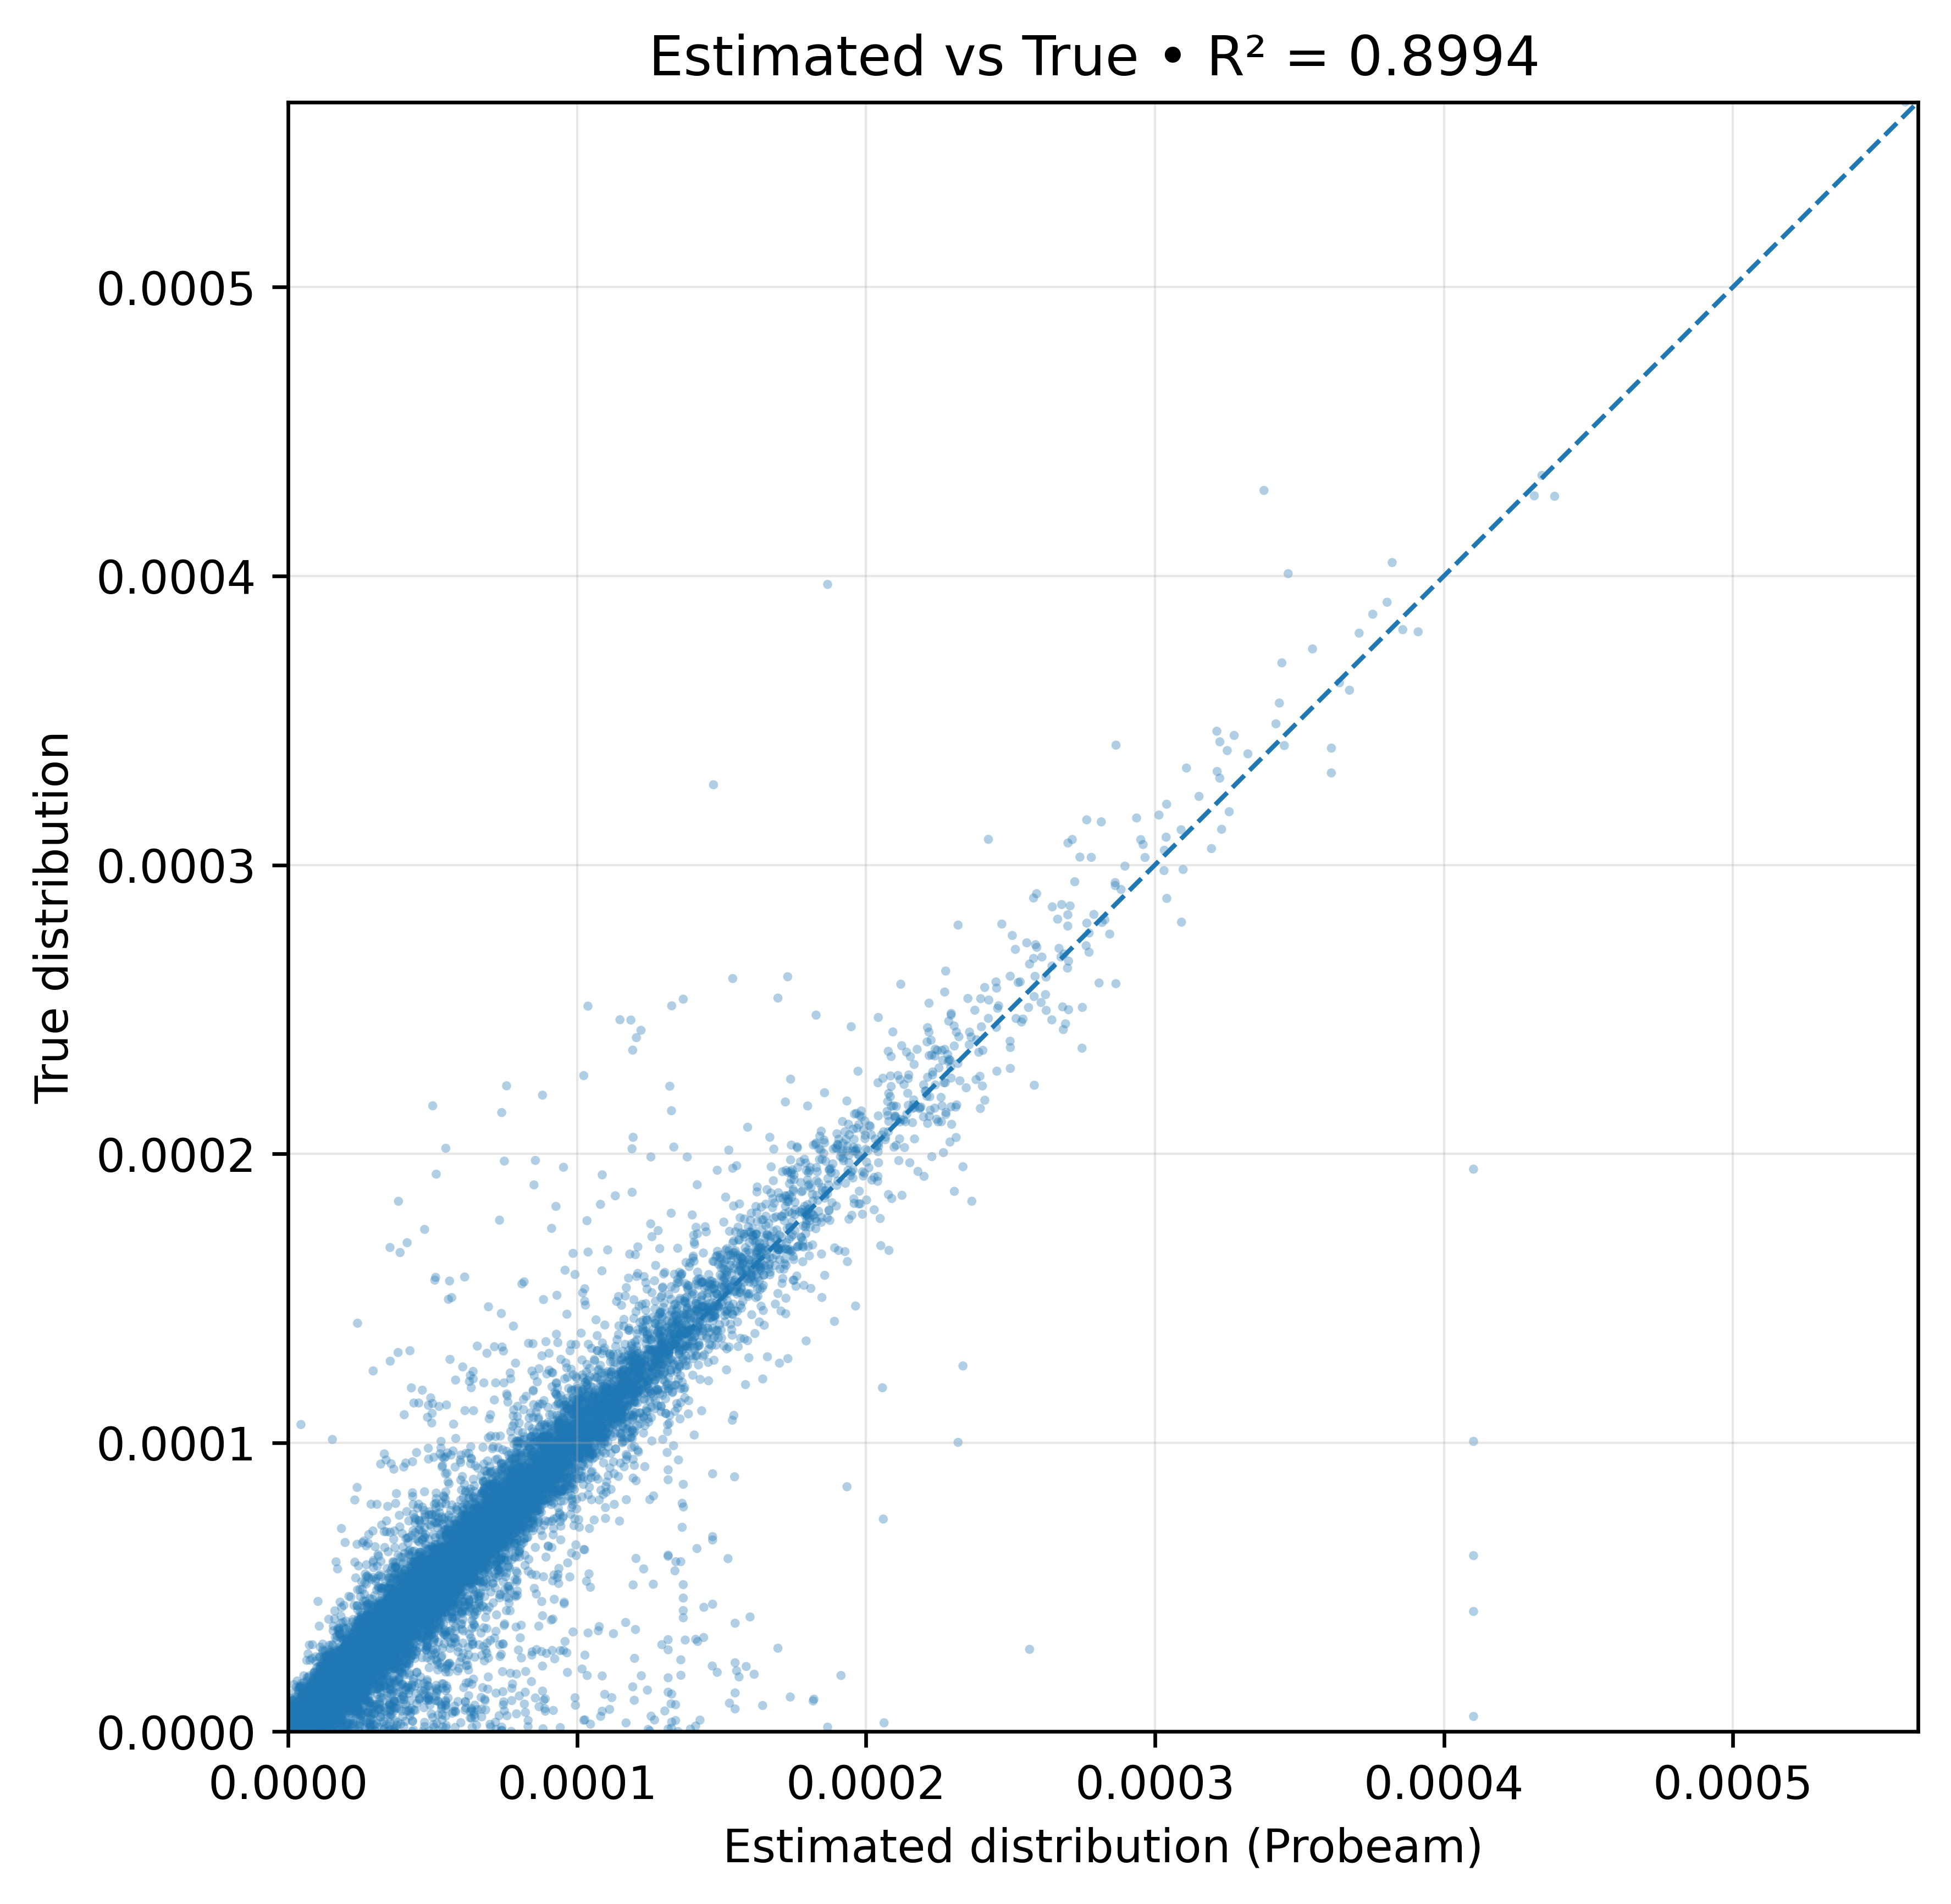

In [73]:

r2, ax = plot_est_vs_true(PY, PhatY_pb, normalize=False)
print("R²:", r2)